In [ ]:
# Import libraries

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load dataset

In [3]:
df = pd.read_csv("customer_shopping_data.csv")

In [4]:
df.shape

(49477, 11)

In [5]:
df.head()

,Invoice_no,Customer_ID,Gender,Age,Category,Quantity_Sold,Unit_Price,Total_Revenue,Payment_Method,Invoice_Date,Shopping_Mall
0,I137065,C736428,Female,46,Food & Beverage,4,20.92,83.68,Cash,01/01/2022,Mall of Istanbul
1,I251307,C240510,Male,58,Shoes,1,600.17,600.17,Debit Card,01/01/2022,Mall of Istanbul
2,I292056,C353878,Female,69,Shoes,3,1800.51,5401.53,Cash,01/01/2022,Istinye Park
3,I570421,C180782,Female,21,Shoes,1,600.17,600.17,Credit Card,01/01/2022,Metrocity
4,I921349,C322855,Female,41,Toys,5,179.20,896.00,Credit Card,01/01/2022,Metrocity


In [6]:
df.tail()

,Invoice_no,Customer_ID,Gender,Age,Category,Quantity_Sold,Unit_Price,Total_Revenue,Payment_Method,Invoice_Date,Shopping_Mall
49472,I132482,C127399,Male,57,Cosmetics,5,203.30,1016.50,Cash,31/01/2023,Mall of Istanbul
49473,I225784,C351029,Male,34,Shoes,1,600.17,600.17,Credit Card,31/01/2023,Mall of Istanbul
49474,I318708,C204031,Female,48,Cosmetics,2,81.32,162.64,Cash,31/01/2023,Emaar Square Mall
49475,I317287,C185135,Male,64,Clothing,1,300.08,300.08,Credit Card,31/01/2023,Mall of Istanbul
49476,I775092,C280958,Female,43,Shoes,1,600.17,600.17,Credit Card,31/01/2023,Viaport Outlet


In [4]:
df.describe()

,Age,Quantity_Sold,Unit_Price,Total_Revenue
count,49477.000000,49477.000000,49477.000000,49477.000000
mean,43.393577,3.007620,687.044083,2524.858296
std,14.986602,1.412827,943.596138,4236.381930
min,18.000000,1.000000,5.230000,5.230000
25%,30.000000,2.000000,40.660000,130.750000
50%,43.000000,3.000000,203.300000,600.170000
75%,56.000000,4.000000,1200.320000,2700.720000
max,69.000000,5.000000,5250.000000,26250.000000


In [ ]:
# 1. Which product categories generate the highest revenue?

In [32]:
df["Category"].describe()

count        49477
unique           8
top       Clothing
freq         16904
Name: Category, dtype: object

In [33]:
df["Total_Revenue"].describe()

count    49477.000000
mean      2524.858296
std       4236.381930
min          5.230000
25%        130.750000
50%        600.170000
75%       2700.720000
max      26250.000000
Name: Total_Revenue, dtype: float64

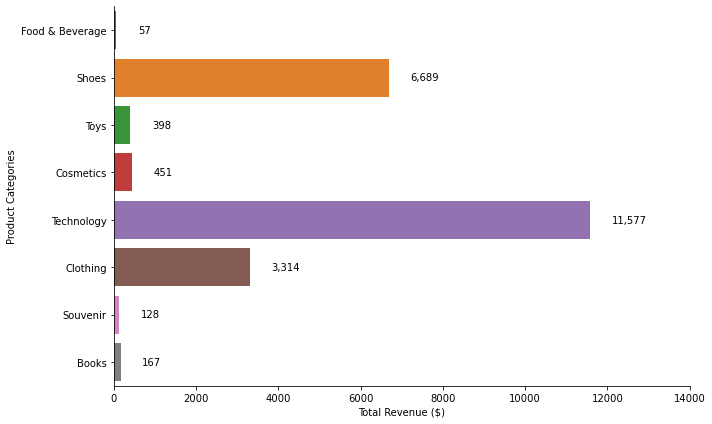

In [ ]:
#Plot
plt.figure(figsize=(10,6), facecolor='white')
ax = sns.barplot(data=df, x="Total_Revenue", y="Category", ci=None)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xlabel("Total Revenue ($)")
plt.ylabel("Product Categories")

#Add value labels
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2

    ax.text(width + 0.02 * df["Total_Revenue"].max(),
    y, f"{width:,.0f}", va='center')

# Set max x-axis value to 14000
plt.xlim(0, 14000)
plt.xticks(np.arange(0, 14001, 2000))

plt.tight_layout()
plt.show()

In [ ]:
# 2. Which product categories sell the highest quantity?

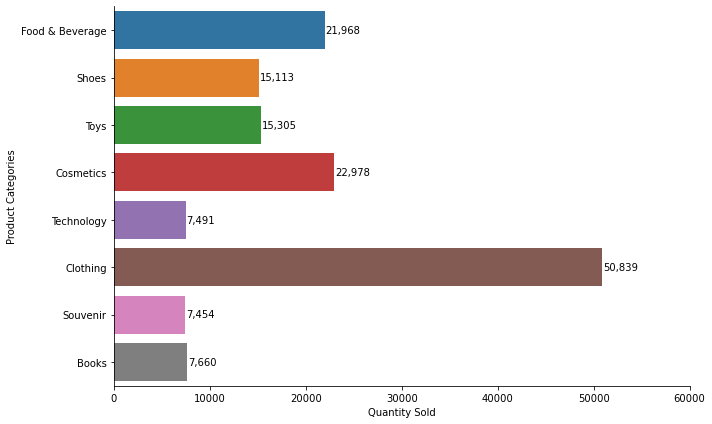

In [13]:
#Plot
plt.figure(figsize=(10,6), facecolor='white')
bx = sns.barplot(data=df, x="Quantity_Sold", y="Category", estimator=sum, ci=None)
bx.spines['right'].set_visible(False)
bx.spines['top'].set_visible(False)
plt.xlabel("Quantity Sold")
plt.ylabel("Product Categories")

#Add label
for p in bx.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height()/2

    bx.text(width + 100, 
    y, f"{width:,.0f}", va='center')
    
# Set xlim
plt.xlim(0, 60000)
plt.xticks(np.arange(0, 60001, 10000))
    
plt.tight_layout()
plt.show()

In [ ]:
# 3. How do products perform across shopping mall locations?

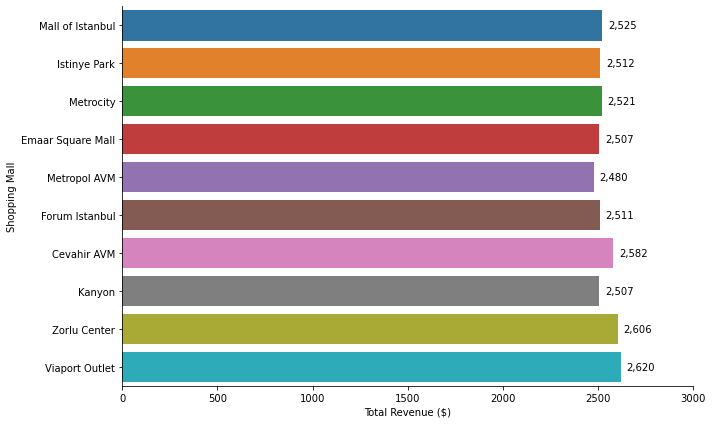

In [9]:
#Plot
plt.figure(figsize=(10,6), facecolor='white')
cx = sns.barplot(data=df, x="Total_Revenue", y="Shopping_Mall", ci=None)
cx.spines['right'].set_visible(False)
cx.spines['top'].set_visible(False)
plt.xlabel("Total Revenue ($)")
plt.ylabel("Shopping Mall")

#Add label
for p in cx.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height()/2

    cx.text(width + 30, 
    y, f"{width:,.0f}", va='center')
    

# Set max x-axis value to 3000
plt.xlim(0, 3000)
plt.xticks(np.arange(0, 3001, 500))
    
plt.tight_layout()
plt.show()

In [ ]:
# 4. How does seasonality influence sales quantities and revenue performance?

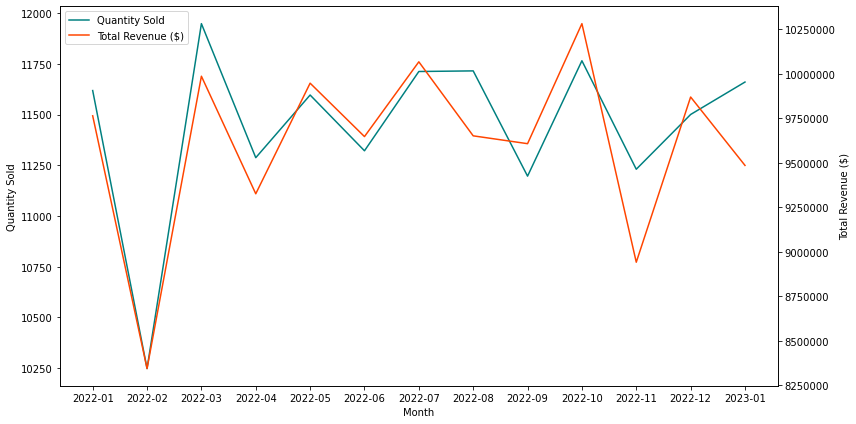

In [10]:
# Convert date column
df['Invoice_Date'] = pd.to_datetime(df['Invoice_Date'], format='%d/%m/%Y')

# Create Year-Month
df['Year_Month'] = df['Invoice_Date'].dt.to_period('M').astype(str)

# Group by month
monthly_data = df.groupby('Year_Month').agg({
    'Quantity_Sold': 'sum',
    'Total_Revenue': 'sum'
})

# Plot 
plt.figure(figsize=(12,6), facecolor='white')

# Left y-axis (Quantity Sold)
ay1 = plt.gca()
line1, = ay1.plot(
    monthly_data.index,
    monthly_data['Quantity_Sold'],
    color='teal',
    label='Quantity Sold'
)
ay1.set_xlabel("Month", color='black')
ay1.set_ylabel("Quantity Sold", color='black')
ay1.tick_params(axis='y', colors='black')

# Right y-axis (Total Revenue)
ay2 = ay1.twinx()
line2, = ay2.plot(
    monthly_data.index,
    monthly_data['Total_Revenue'],
    color='orangered',
    label='Total Revenue ($)'
)
ay2.set_ylabel("Total Revenue ($)", color='black')
ay2.tick_params(axis='y', colors='black')

# Disable scientific notation
ay2.ticklabel_format(style='plain', axis='y')

plt.legend(handles=[line1, line2], loc='upper left')
#plt.title("Quantity Sold and Total Revenue by Month (Dual Y-Axis)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 5. How do age and gender influence sale quantities?

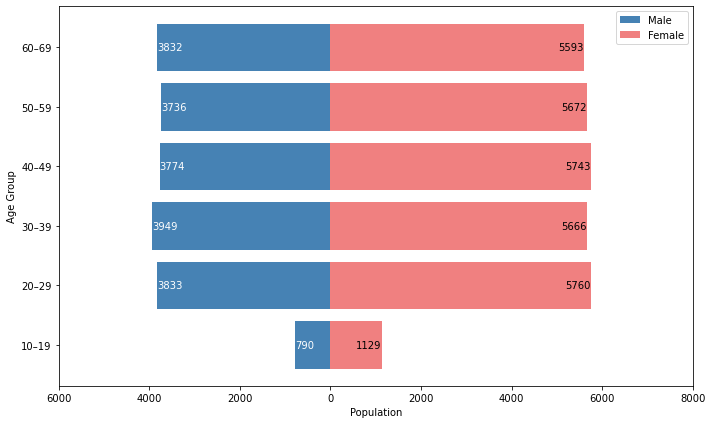

In [12]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 120]
labels = ["0–9","10–19","20–29","30–39","40–49",
          "50–59","60–69","70–79","80–89","90+"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=False)

# Group by Age Group and Gender
pop = df.groupby(["Age_Group", "Gender"]).size().unstack(fill_value=0)

# Exclude empty age groups
pop = pop[pop.sum(axis=1) > 0]

# Convert male to negative (for left side)
male = -pop.get("Male", pd.Series(0, index=pop.index))
female =  pop.get("Female", pd.Series(0, index=pop.index))

# Plot Population Pyramid
plt.figure(figsize=(10, 6), facecolor='white')

bars_m = plt.barh(pop.index, male, color="steelblue", label="Male")
bars_f = plt.barh(pop.index, female, color="lightcoral", label="Female")

plt.xlabel("Population")
plt.ylabel("Age Group")

# Force x-axis labels to show positive values
ticks = plt.xticks()[0]
plt.xticks(ticks, [abs(int(x)) for x in ticks])

plt.legend()
plt.tight_layout()

# Add labels
for bar in bars_m:
    width = bar.get_width()  
    plt.text(width + 5, bar.get_y() + bar.get_height()/2,
             f"{abs(int(width))}", va='center', ha='left', color='white')

for bar in bars_f:
    width = bar.get_width()  
    plt.text(width - 5, bar.get_y() + bar.get_height()/2,
             f"{int(width)}", va='center', ha='right', color='black')

plt.show()

In [ ]:
# 6. Which payment method is most used by customers? 

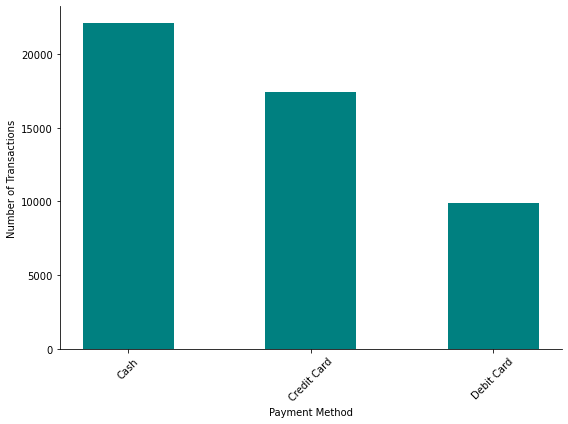

In [54]:
# Count payment methods
payment_counts = df["Payment_Method"].value_counts()

# Plot bar chart
plt.figure(figsize=(8,6), facecolor='white')
gx = plt.bar(payment_counts.index, payment_counts.values, color="teal", width = 0.5)
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
#plt.title("Distribution of Payment Method Usage")
plt.xticks(rotation=45)

gx = plt.gca()
gx.spines['right'].set_visible(False)
gx.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()